# Phase 5 — Real-Time Facial Recognition with Emotion & Liveness


## Imports

In [2]:
import os
import json
import pickle
import time
import csv
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
from PIL import Image, ImageTk

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from facenet_pytorch import MTCNN

import tkinter as tk
from tkinter import ttk, filedialog, simpledialog, messagebox

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Device setup

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available. will run on  CPU.")

Device: cpu
CUDA is not available. will run on  CPU.


## Project paths


In [4]:
# Default local project path used in Phase 1 and Phase 2
PROJECT_ROOT = Path(r"/Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project")

MODEL_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REGISTRY_DIR = PROJECT_ROOT / "phase5_registry"
LOG_DIR = PROJECT_ROOT / "phase5_logs"

REGISTRY_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

CLF_MODEL_PATH = MODEL_DIR / "clf_model_best.pth"
TRIP_MODEL_PATH = MODEL_DIR / "trip_model_final.pth"
SPOOF_MODEL_PATH = MODEL_DIR / "spoof_model_best.pth"
EMOTION_MODEL_PATH = MODEL_DIR / "emotion_model.pkl"
BEST_INFO_PATH = OUTPUTS_DIR / "phase2_best_face_verification_info.json"

REGISTRY_PATH = REGISTRY_DIR / "face_registry.npz"
ATTENDANCE_LOG_PATH = LOG_DIR / "attendance_log.csv"

#Testing if all files exist 
print("PROJECT_ROOT:", PROJECT_ROOT)
print("\nRequired models/files:")
for path in [CLF_MODEL_PATH, TRIP_MODEL_PATH, SPOOF_MODEL_PATH, EMOTION_MODEL_PATH, BEST_INFO_PATH]:
    print(f"{path.name:45s}", path.exists(), "→", path)

PROJECT_ROOT: /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project

Required models/files:
clf_model_best.pth                            True → /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/models/clf_model_best.pth
trip_model_final.pth                          True → /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/models/trip_model_final.pth
spoof_model_best.pth                          True → /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/models/spoof_model_best.pth
emotion_model.pkl                             True → /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/models/emotion_model.pkl
phase2_best_face_verification_info.json       True → /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/outputs/phase2_best_face_verification_info.json


## Loading Phase 2 best recognition information

In [37]:
with open(BEST_INFO_PATH, "r") as f:
    best_info = json.load(f)

BEST_CONFIGURATION = best_info["best_configuration"]
BEST_THRESHOLD = float(best_info["best_threshold"])

print("Best Phase 2 configuration:", BEST_CONFIGURATION)
print("Best threshold:", BEST_THRESHOLD)

Best Phase 2 configuration: Triplet ResNet18 + cosine
Best threshold: 0.3363700807094574


## Model class definitions


In [ ]:
class FaceEmbedderClassification(nn.Module):
    def __init__(self, num_classes=4000, embedding_dim=512):
        super().__init__()
        base = models.mobilenet_v2(weights=None)
        self.backbone = base.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.embedder = nn.Sequential(
            nn.Linear(1280, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU()
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        x = self.backbone(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        emb = self.embedder(x)
        emb = F.normalize(emb, p=2, dim=1)
        if return_embedding:
            return emb
        return self.classifier(emb)


class FaceEmbedderTriplet(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        base = models.resnet18(weights=None)
        in_features = base.fc.in_features
        base.fc = nn.Identity()
        self.backbone = base
        self.head = nn.Sequential(
            nn.Linear(in_features, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

    def forward(self, x):
        x = self.backbone(x)
        emb = self.head(x)
        emb = F.normalize(emb, p=2, dim=1)
        return emb


class AntiSpoofModel(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.mobilenet_v2(weights=None)
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.4):
        super().__init__()
        self.model = models.mobilenet_v2(weights=None)
        self.model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

## Load all models

In [39]:
def load_state_dict_safely(model, model_path):
    checkpoint = torch.load(model_path, map_location=device)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        checkpoint = checkpoint["model_state_dict"]
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    return model

# Face recognition models
clf_model = FaceEmbedderClassification(num_classes=4000, embedding_dim=512)
clf_model = load_state_dict_safely(clf_model, CLF_MODEL_PATH)

trip_model = FaceEmbedderTriplet(embedding_dim=256)
trip_model = load_state_dict_safely(trip_model, TRIP_MODEL_PATH)

# Liveness model
spoof_model = AntiSpoofModel()
spoof_model = load_state_dict_safely(spoof_model, SPOOF_MODEL_PATH)

# Emotion model saved inside a pickle dictionary
with open(EMOTION_MODEL_PATH, "rb") as f:
    emotion_data = pickle.load(f)

emotion_classes = emotion_data.get(
    "emotions",
    ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
)

emotion_model = EmotionCNN(num_classes=len(emotion_classes), dropout=0.4)
emotion_model.load_state_dict(emotion_data["model_state_dict"])
emotion_model.to(device)
emotion_model.eval()

print("All models loaded successfully.")
print("Emotion classes:", emotion_classes)

All models loaded successfully.
Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## MTCNN and preprocessing pipelines

In [40]:
mtcnn = MTCNN(
    image_size=112,
    margin=20,
    keep_all=False,
    post_process=False,
    device=device
)

recognition_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

spoof_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

emotion_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Face detection helper

In [ ]:
def detect_face(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(frame_rgb)

    boxes, probs = mtcnn.detect(pil_img)
    if boxes is None or len(boxes) == 0:
        return None, None

    valid_probs = np.array([p if p is not None else 0 for p in probs])
    best_idx = int(np.argmax(valid_probs))
    box = boxes[best_idx]

    x1, y1, x2, y2 = box
    x1 = max(0, int(x1))
    y1 = max(0, int(y1))
    x2 = min(pil_img.width, int(x2))
    y2 = min(pil_img.height, int(y2))

    if x2 <= x1 or y2 <= y1:
        return None, None

    face_pil = pil_img.crop((x1, y1, x2, y2))
    return face_pil, (x1, y1, x2, y2)

## Prediction helper functions

In [ ]:
@torch.no_grad()
def get_face_embeddings(face_pil):
    x = recognition_transform(face_pil).unsqueeze(0).to(device)
    clf_emb = clf_model(x, return_embedding=True)
    trip_emb = trip_model(x)
    return clf_emb.cpu().numpy()[0], trip_emb.cpu().numpy()[0]


@torch.no_grad()
def predict_liveness(face_pil):
    x = spoof_transform(face_pil).unsqueeze(0).to(device)
    logits = spoof_model(x)
    probs = F.softmax(logits, dim=1)[0]
    pred_idx = int(torch.argmax(probs).item())
    confidence = float(probs[pred_idx].item())
    real_prob = float(probs[1].item())

    # Softer threshold for webcam testing
    REAL_THRESHOLD = 0.30

    label = "real" if real_prob >= REAL_THRESHOLD else "spoof"

    return label, confidence, real_prob


@torch.no_grad()
def predict_emotion(face_pil):
    x = emotion_transform(face_pil).unsqueeze(0).to(device)
    logits = emotion_model(x)
    probs = F.softmax(logits, dim=1)[0]
    pred_idx = int(torch.argmax(probs).item())
    confidence = float(probs[pred_idx].item())
    emotion = emotion_classes[pred_idx]
    return emotion, confidence


def cosine_score(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

## Face registry system

In [43]:
def load_registry():
    if not REGISTRY_PATH.exists():
        return [], np.empty((0, 512), dtype=np.float32), np.empty((0, 256), dtype=np.float32)

    data = np.load(REGISTRY_PATH, allow_pickle=True)
    names = list(data["names"])
    clf_embeddings = data["clf_embeddings"].astype(np.float32)
    trip_embeddings = data["trip_embeddings"].astype(np.float32)
    return names, clf_embeddings, trip_embeddings


def save_registry(names, clf_embeddings, trip_embeddings):
    np.savez(
        REGISTRY_PATH,
        names=np.array(names, dtype=object),
        clf_embeddings=np.array(clf_embeddings, dtype=np.float32),
        trip_embeddings=np.array(trip_embeddings, dtype=np.float32)
    )
    print("Registry saved:", REGISTRY_PATH)


def add_person_to_registry(name, clf_embs, trip_embs):
    names, clf_registry, trip_registry = load_registry()

    clf_avg = np.mean(np.array(clf_embs), axis=0)
    trip_avg = np.mean(np.array(trip_embs), axis=0)

    # Normalize after averaging
    clf_avg = clf_avg / (np.linalg.norm(clf_avg) + 1e-8)
    trip_avg = trip_avg / (np.linalg.norm(trip_avg) + 1e-8)

    names.append(name)
    clf_registry = np.vstack([clf_registry, clf_avg.reshape(1, -1)])
    trip_registry = np.vstack([trip_registry, trip_avg.reshape(1, -1)])

    save_registry(names, clf_registry, trip_registry)
    print(f"Registered: {name}")
    print(f"Total registered people: {len(names)}")


def clear_registry():
    if REGISTRY_PATH.exists():
        REGISTRY_PATH.unlink()
        print("Registry cleared.")
    else:
        print("Registry is already empty.")

## Recognition function

In [44]:
def recognise_person(clf_emb, trip_emb):
    names, clf_registry, trip_registry = load_registry()

    if len(names) == 0:
        return {
            "final_name": "Unknown",
            "clf_name": "None",
            "trip_name": "None",
            "clf_score": 0.0,
            "trip_score": 0.0,
            "decision_model": BEST_CONFIGURATION,
            "threshold": BEST_THRESHOLD
        }

    clf_scores = [cosine_score(clf_emb, reg_emb) for reg_emb in clf_registry]
    trip_scores = [cosine_score(trip_emb, reg_emb) for reg_emb in trip_registry]

    clf_best_idx = int(np.argmax(clf_scores))
    trip_best_idx = int(np.argmax(trip_scores))

    clf_best_score = float(clf_scores[clf_best_idx])
    trip_best_score = float(trip_scores[trip_best_idx])

    clf_name = names[clf_best_idx]
    trip_name = names[trip_best_idx]

    # Final identity decision uses Phase 2 best model
    if "Triplet" in BEST_CONFIGURATION:
        final_score = trip_best_score
        final_name_candidate = trip_name
    else:
        final_score = clf_best_score
        final_name_candidate = clf_name

    final_name = final_name_candidate if final_score >= BEST_THRESHOLD else "Unknown"

    return {
        "final_name": final_name,
        "clf_name": clf_name,
        "trip_name": trip_name,
        "clf_score": clf_best_score,
        "trip_score": trip_best_score,
        "decision_model": BEST_CONFIGURATION,
        "threshold": BEST_THRESHOLD
    }

## Folder registration


In [ ]:
def register_from_folder(person_name, folder_path, max_images=30):
    folder_path = Path(folder_path)
    if not folder_path.exists():
        print("Folder does not exist:", folder_path)
        return False

    image_paths = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
        image_paths.extend(list(folder_path.glob(ext)))

    image_paths = image_paths[:max_images]
    if len(image_paths) == 0:
        print("No images found in folder.")
        return False

    clf_embs = []
    trip_embs = []

    print(f"Registering {person_name} from {len(image_paths)} images...")

    for img_path in image_paths:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            print("Could not read:", img_path.name)
            continue

        face_pil, box = detect_face(img_bgr)
        if face_pil is None:
            print("No face detected:", img_path.name)
            continue

        live_label, live_conf, real_prob = predict_liveness(face_pil)
        if live_label != "real":
            print(f"Skipped possible spoof image: {img_path.name} | real_prob={real_prob:.2f}")
            continue

        clf_emb, trip_emb = get_face_embeddings(face_pil)
        clf_embs.append(clf_emb)
        trip_embs.append(trip_emb)

    if len(clf_embs) == 0:
        print("No usable real faces found.")
        return False

    add_person_to_registry(person_name, clf_embs, trip_embs)
    print(f"Folder registration complete for {person_name}.")
    return True

## Attendance logging

In [46]:
def log_attendance(name, liveness, emotion, clf_score, trip_score):
    file_exists = ATTENDANCE_LOG_PATH.exists()

    with open(ATTENDANCE_LOG_PATH, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)

        if not file_exists:
            writer.writerow([
                "timestamp",
                "name",
                "liveness",
                "emotion",
                "clf_score",
                "trip_score",
                "decision_model"
            ])

        writer.writerow([
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            name,
            liveness,
            emotion,
            round(clf_score, 4),
            round(trip_score, 4),
            BEST_CONFIGURATION
        ])

## Polished Tkinter UI

In [ ]:
class FaceSystemApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Phase 5 — Facial Recognition with Emotion & Liveness")
        self.root.geometry("980x720")
        self.root.configure(bg="#121212")
        self.root.resizable(True, True)

        self.cap = None
        self.running = False
        self.last_logged_name = None
        self.last_log_time = 0
        self.log_cooldown = 10  # seconds

        self.current_face_pil = None
        self.frame_count = 0
        self.process_every_n_frames = 3
        
        self.video_w = 820
        self.video_h = 430

        self.last_status = {
            "name": "Waiting...",
            "liveness": "-",
            "emotion": "-",
            "clf_score": 0.0,
            "trip_score": 0.0
        }

        self.setup_ui()

    def setup_ui(self):
        for widget in self.root.winfo_children():
            widget.destroy()

        title = tk.Label(
            self.root,
            text="Facial Recognition Attendance System",
            font=("Arial", 20, "bold"),
            fg="white",
            bg="#121212"
        )
        title.pack(pady=(10, 6))

        # Camera panel 
        self.blank_image = ImageTk.PhotoImage(
            Image.new("RGB", (self.video_w, self.video_h), (0, 0, 0))
        )

        self.video_label = tk.Label(
            self.root,
            image=self.blank_image,
            bg="#000000",
            bd=2,
            relief="solid"
        )
        self.video_label.image = self.blank_image
        self.video_label.pack(pady=6)

        # Info panel
        info_frame = tk.Frame(self.root, bg="#1f1f1f")
        info_frame.pack(fill="x", padx=20, pady=6)

        self.name_var = tk.StringVar(value="Name: Waiting...")
        self.live_var = tk.StringVar(value="Liveness: -")
        self.emotion_var = tk.StringVar(value="Emotion: -")
        self.clf_var = tk.StringVar(value="CLF Score: -")
        self.trip_var = tk.StringVar(value="TRIP Score: -")
        self.final_var = tk.StringVar(value=f"Decision Model: {BEST_CONFIGURATION}")
        self.threshold_var = tk.StringVar(value=f"Threshold: {BEST_THRESHOLD:.4f}")

        info_items = [
            self.name_var,
            self.live_var,
            self.emotion_var,
            self.clf_var,
            self.trip_var,
            self.final_var,
            self.threshold_var
        ]

        for i, var in enumerate(info_items):
            label = tk.Label(
                info_frame,
                textvariable=var,
                font=("Arial", 11),
                fg="#e8e8e8",
                bg="#1f1f1f",
                anchor="w"
            )
            label.grid(row=i // 2, column=i % 2, sticky="w", padx=15, pady=4)

        info_frame.grid_columnconfigure(0, weight=1)
        info_frame.grid_columnconfigure(1, weight=1)

        # Button panel 
        button_frame = tk.Frame(self.root, bg="#121212")
        button_frame.pack(pady=6)

        btn_style = {
            "font": ("Arial", 10, "bold"),
            "width": 18,
            "height": 2,
            "bd": 0
        }

        self.start_btn = tk.Button(
            button_frame,
            text="Start Camera",
            command=self.start_camera,
            bg="#2e7d32",
            fg="white",
            **btn_style
        )
        self.start_btn.grid(row=0, column=0, padx=5, pady=4)

        self.stop_btn = tk.Button(
            button_frame,
            text="Stop Camera",
            command=self.stop_camera,
            bg="#c62828",
            fg="white",
            **btn_style
        )
        self.stop_btn.grid(row=0, column=1, padx=5, pady=4)

        self.webcam_reg_btn = tk.Button(
            button_frame,
            text="Register Webcam",
            command=self.register_current_face,
            bg="#1565c0",
            fg="white",
            **btn_style
        )
        self.webcam_reg_btn.grid(row=0, column=2, padx=5, pady=4)

        self.folder_reg_btn = tk.Button(
            button_frame,
            text="Register Folder",
            command=self.register_folder_ui,
            bg="#6a1b9a",
            fg="white",
            **btn_style
        )
        self.folder_reg_btn.grid(row=0, column=3, padx=5, pady=4)

        self.registry_btn = tk.Button(
            button_frame,
            text="Show Registry",
            command=self.show_registry_count,
            bg="#424242",
            fg="white",
            **btn_style
        )
        self.registry_btn.grid(row=1, column=1, columnspan=2, padx=5, pady=4)

        self.status_bar = tk.Label(
            self.root,
            text="Ready.",
            font=("Arial", 10),
            fg="#bbbbbb",
            bg="#121212",
            anchor="w"
        )
        self.status_bar.pack(fill="x", padx=20, pady=(3, 5))

    def start_camera(self):
        if self.running:
            return

        self.cap = cv2.VideoCapture(1)

        if not self.cap.isOpened():
            messagebox.showerror("Camera Error", "Could not open webcam.")
            return

        self.running = True
        self.status_bar.config(text="Camera started.")
        self.update_frame()

    def stop_camera(self):
        self.running = False

        if self.cap is not None:
            self.cap.release()
            self.cap = None

        # Reset to blank image
        self.video_label.configure(image=self.blank_image)
        self.video_label.image = self.blank_image
        self.status_bar.config(text="Camera stopped.")

    def update_frame(self):
        if not self.running or self.cap is None:
            return

        ret, frame = self.cap.read()

        if not ret:
            self.status_bar.config(text="Failed to read camera frame.")
            self.root.after(30, self.update_frame)
            return

        display_frame = frame.copy()
        self.frame_count += 1

        # Only run full ML pipeline every few frames for smoother UI
        run_model_now = self.frame_count % self.process_every_n_frames == 0

        face_pil, box = detect_face(frame)

        if face_pil is None:
            self.current_face_pil = None
            self.update_status("No face detected", "-", "-", 0.0, 0.0)

        else:
            self.current_face_pil = face_pil

            x1, y1, x2, y2 = box
            cv2.rectangle(display_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

            if run_model_now:
                live_label, live_conf, real_prob = predict_liveness(face_pil)

                if live_label == "spoof":
                    self.last_status = {
                        "name": "Blocked",
                        "liveness": f"SPOOF | Real prob: {real_prob:.2f}",
                        "emotion": "-",
                        "clf_score": 0.0,
                        "trip_score": 0.0
                    }

                else:
                    emotion, emotion_conf = predict_emotion(face_pil)

                    clf_emb, trip_emb = get_face_embeddings(face_pil)
                    rec = recognise_person(clf_emb, trip_emb)

                    name = rec["final_name"]
                    clf_score = rec["clf_score"]
                    trip_score = rec["trip_score"]

                    self.last_status = {
                        "name": name,
                        "liveness": f"REAL ({real_prob:.2f})",
                        "emotion": f"{emotion} ({emotion_conf:.2f})",
                        "clf_score": clf_score,
                        "trip_score": trip_score
                    }

                    if name != "Unknown":
                        now = time.time()

                        if name != self.last_logged_name or now - self.last_log_time > self.log_cooldown:
                            log_attendance(
                                name=name,
                                liveness="real",
                                emotion=emotion,
                                clf_score=clf_score,
                                trip_score=trip_score
                            )

                            self.last_logged_name = name
                            self.last_log_time = now

            self.update_status(
                self.last_status["name"],
                self.last_status["liveness"],
                self.last_status["emotion"],
                self.last_status["clf_score"],
                self.last_status["trip_score"]
            )

            if "SPOOF" in self.last_status["liveness"]:
                label_text = "SPOOF DETECTED"
                color = (0, 0, 255)
            else:
                emotion_text = self.last_status["emotion"].split(" ")[0]
                label_text = f"{self.last_status['name']} | {emotion_text}"
                color = (0, 255, 0)

            cv2.putText(
                display_frame,
                label_text,
                (x1, max(30, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                color,
                2
            )

        frame_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame_rgb).resize((self.video_w, self.video_h))

        imgtk = ImageTk.PhotoImage(image=img)

        self.video_label.imgtk = imgtk
        self.video_label.configure(image=imgtk)

        self.root.after(30, self.update_frame)

    def update_status(self, name, liveness, emotion, clf_score, trip_score):
        self.name_var.set(f"Name: {name}")
        self.live_var.set(f"Liveness: {liveness}")
        self.emotion_var.set(f"Emotion: {emotion}")
        self.clf_var.set(f"CLF Score: {clf_score:.4f}")
        self.trip_var.set(f"TRIP Score: {trip_score:.4f}")
        self.final_var.set(f"Decision Model: {BEST_CONFIGURATION}")
        self.threshold_var.set(f"Threshold: {BEST_THRESHOLD:.4f}")

    def register_current_face(self):
        if self.cap is None or not self.running:
            messagebox.showwarning("Camera Off", "Start the camera first.")
            return

        name = simpledialog.askstring("Register Person", "Enter name or ID:")

        if name is None or name.strip() == "":
            return

        name = name.strip()

        clf_embs = []
        trip_embs = []

        captures_needed = 10
        captured = 0

        messagebox.showinfo(
            "Webcam Registration",
            f"Capturing {captures_needed} real-face samples. Keep your face visible."
        )

        start_time = time.time()

        while captured < captures_needed and time.time() - start_time < 20:
            ret, frame = self.cap.read()

            if not ret:
                continue

            face_pil, box = detect_face(frame)

            if face_pil is None:
                continue

            live_label, live_conf, real_prob = predict_liveness(face_pil)

            if live_label != "real":
                continue

            clf_emb, trip_emb = get_face_embeddings(face_pil)

            clf_embs.append(clf_emb)
            trip_embs.append(trip_emb)

            captured += 1
            time.sleep(0.15)

        if captured == 0:
            messagebox.showerror("Registration Failed", "No usable real-face samples captured.")
            return

        add_person_to_registry(name, clf_embs, trip_embs)

        messagebox.showinfo(
            "Registered",
            f"{name} registered successfully using {captured} samples."
        )

        self.status_bar.config(text=f"Registered {name} from webcam.")

    def register_folder_ui(self):
        folder = filedialog.askdirectory(title="Select folder of face images")

        if not folder:
            return

        name = simpledialog.askstring("Register Person", "Enter name or ID:")

        if name is None or name.strip() == "":
            return

        name = name.strip()

        success = register_from_folder(name, folder)

        if success:
            messagebox.showinfo("Registered", f"{name} registered from folder.")
            self.status_bar.config(text=f"Registered {name} from folder.")
        else:
            messagebox.showerror(
                "Registration Failed",
                "No usable real-face samples found in the selected folder."
            )

    def show_registry_count(self):
        names, _, _ = load_registry()

        if len(names) == 0:
            preview = "No registered people yet."
        else:
            preview = "\n".join([str(n) for n in names[:20]])

        messagebox.showinfo(
            "Registry",
            f"Registered people: {len(names)}\n\n{preview}"
        )

    def on_close(self):
        self.stop_camera()
        self.root.destroy()


## Launch Phase 5 system


In [48]:
root = tk.Tk()
app = FaceSystemApp(root)
root.protocol("WM_DELETE_WINDOW", app.on_close)
root.mainloop()

## Testing Camera


Camera index 0: False
Camera index 1: True


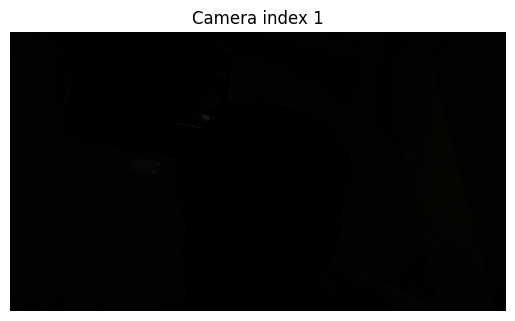

[05/31 18:15:23.309720][info][4008514][Context.cpp:69] Context created with config: default config!
[05/31 18:15:23.309757][info][4008514][Context.cpp:74] Context work_dir=/Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project
[05/31 18:15:23.309759][info][4008514][Context.cpp:77] 	- SDK version: 1.9.4
[05/31 18:15:23.309760][info][4008514][Context.cpp:78] 	- SDK stage version: main
[05/31 18:15:23.309762][info][4008514][Context.cpp:82] get config EnumerateNetDevice:false
[05/31 18:15:23.309959][info][4008514][MacPal.cpp:36] createObPal: create MacPal!
[05/31 18:15:23.311175][info][4008514][MacPal.cpp:104] Create PollingDeviceWatcher!
[05/31 18:15:23.311182][info][4008514][DeviceManager.cpp:15] Current found device(s): (0)
[05/31 18:15:23.311194][info][4008514][Pipeline.cpp:15] Try to create pipeline with default device.
[05/31 18:15:23.311196][warning][4008514][ObException.cpp:5] No device found, fail to create pipeline!
[05/31 18:15:23.312930][info][4008514][Context.cpp:90] Cont

OpenCV: out device of bound (0-1): 2
OpenCV: camera failed to properly initialize!
[ WARN:0@16305.450] global cap.cpp:323 open VIDEOIO(OBSENSOR): raised unknown C++ exception!


OpenCV: out device of bound (0-1): 3
OpenCV: camera failed to properly initialize!
[ WARN:0@16305.463] global cap.cpp:323 open VIDEOIO(OBSENSOR): raised unknown C++ exception!


OpenCV: out device of bound (0-1): 4
OpenCV: camera failed to properly initialize!
[ WARN:0@16305.475] global cap.cpp:323 open VIDEOIO(OBSENSOR): raised unknown C++ exception!




In [49]:
import cv2
import matplotlib.pyplot as plt

for i in range(5):
    cap = cv2.VideoCapture(i)
    ret, frame = cap.read()
    cap.release()

    print(f"Camera index {i}: {ret}")

    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frame_rgb)
        plt.title(f"Camera index {i}")
        plt.axis("off")
        plt.show()